# Aula 4 — Regressão Linear
## *Ou: como transformar uma correlação em uma previsão*

> **Data:** *(preencher)*  
> **Professor(a):** *(preencher)*

## 🤔 Antes de começar: da correlação para a previsão

Na **Aula 3** vocês aprenderam a *medir* a relação entre duas variáveis. Fizeram heatmaps,
olharam para a correlação e concluíram coisas do tipo: *"essas duas variáveis andam juntas"*.

Só que correlação responde apenas **"andam juntas?"** e **"o quanto?"**.

Ela não responde a pergunta que todo mundo quer fazer:

> *"Beleza, andam juntas. Mas então **quanto** eu devo esperar de preço para um diamante de 1,2 quilate?"*

É aqui que entra a **Regressão Linear**. Em vez de só medir a força da relação, ela **traça uma
reta** que descreve essa relação, e com essa reta você consegue *prever* valores.

```
Aula 3:  "carat e price têm correlação de 0,92"     → mede a relação
Aula 4:  "cada quilate a mais vale ~US$ 7,8 mil"    → quantifica e prevê
```

**É o mesmo fenômeno, mas agora com um número na ponta.**

## 1. Nosso problema de hoje: o preço dos diamantes 💎

Vamos trabalhar com o dataset **diamonds**, que contém informações sobre ~54.000 diamantes.

Hoje vamos usar apenas as colunas **numéricas**, porque regressão linear trabalha com números e
ainda não aprendemos a converter texto em número (isso fica para a Aula 5).

| Coluna | O que é |
|---|---|
| `carat` | Peso do diamante em quilates (tamanho) |
| `depth` | Profundidade percentual |
| `table` | Largura do topo em relação ao ponto mais largo |
| `x`, `y`, `z` | Dimensões físicas em mm |
| `price` | **Preço em dólares (nosso alvo!)** |

**Nosso objetivo:** prever o preço (`price`) a partir das características numéricas.

Vamos carregar os dados:

In [1]:
# Importando as bibliotecas que vamos usar
import shutil
import urllib.request
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Na primeira vez a base é baixada para data_raw/ (o original, que fica de
# referência) e copiada para data/ (a cópia de trabalho, que é a que vamos usar).
# Bagunçou a base? Apague data/diamonds.csv e rode esta célula de novo.
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
Path('data_raw').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

if not Path('data_raw/diamonds.csv').exists():
    print('Baixando diamonds.csv...')
    urllib.request.urlretrieve(url, 'data_raw/diamonds.csv')
if not Path('data/diamonds.csv').exists():
    shutil.copy('data_raw/diamonds.csv', 'data/diamonds.csv')

df = pd.read_csv('data/diamonds.csv')

# Primeiras linhas
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Relembrando a Aula 3: quem anda junto com o preço?

Antes de traçar qualquer reta, vale olhar o **heatmap de correlação**, exatamente como fizemos na
aula passada.

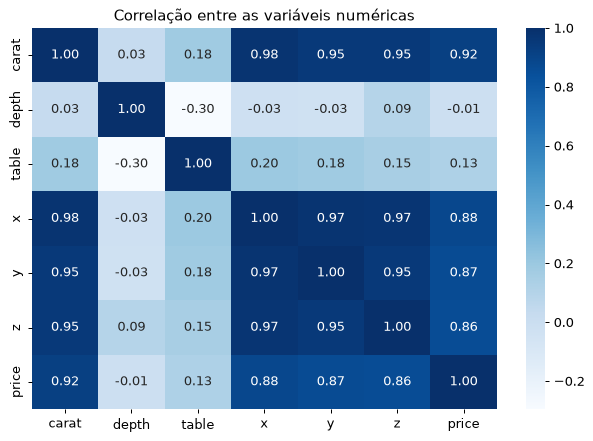

In [2]:
# Só as colunas numéricas
numericas = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

plt.figure(figsize=(7, 5))
sns.heatmap(df[numericas].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlação entre as variáveis numéricas')
plt.tight_layout()
plt.show()

**O que o heatmap conta:**

* `carat` tem correlação altíssima com `price` (~0,92): diamante maior, preço maior. Sem surpresa.
* `x`, `y`, `z` (as dimensões físicas) também são fortemente correlacionadas com o preço, e
  também **entre si**, porque todas medem "tamanho". Guarde essa informação, ela volta no fim da aula.
* `depth` e `table` quase não se correlacionam com o preço.

Até aqui, nada novo. Vamos olhar a relação mais forte de perto, num scatterplot:

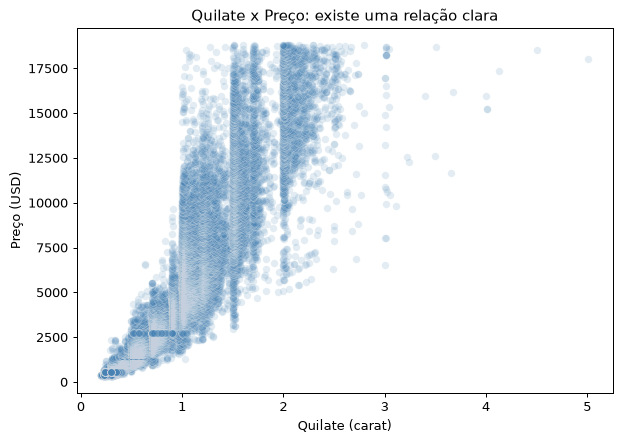

In [3]:
# A relação mais forte da base: quilate x preço
plt.figure(figsize=(7, 5))
sns.scatterplot(x='carat', y='price', data=df, alpha=0.15, color='steelblue')
plt.title('Quilate x Preço: existe uma relação clara')
plt.xlabel('Quilate (carat)')
plt.ylabel('Preço (USD)')
plt.tight_layout()
plt.show()

Olhando esse gráfico, seu cérebro já está fazendo regressão sozinho: você **imagina uma linha**
passando no meio da nuvem de pontos.

A Regressão Linear faz isso de forma matemática, e sem chute.

## 2. Regressão Linear: o modelo mais honesto do mundo

### O que é?

Regressão Linear é um modelo que tenta encontrar uma **linha reta** que melhor representa a relação
entre as variáveis de entrada e o resultado.

### Analogia: previsão de salário

Imagine que você sabe que:

* Com 0 anos de experiência, o salário é R$ 3.000
* Com 5 anos, o salário é R$ 8.000

Regressão linear traçaria uma reta entre esses pontos e usaria ela para prever: *"com 3 anos de
experiência, o salário deve ser uns R$ 6.000"*.

### A fórmula (sem entrar em pânico)

A fórmula básica é:

```
preço = a₁ × quilate + a₂ × profundidade + a₃ × largura + ... + b
```

Onde:

* **a₁, a₂, a₃...** são os **coeficientes** (o peso de cada característica)
* **b** é o **intercepto** (o valor base quando tudo é zero)

O modelo aprende esses valores durante o treinamento.

### E como ele escolhe "a melhor" reta?

Entre todas as retas possíveis, o modelo escolhe aquela que deixa os pontos **o mais perto possível**
dela. Em outras palavras: a reta que **minimiza a soma dos erros ao quadrado**.

É por isso que a regressão linear é honesta: ela não esconde o erro, é literalmente construída para
deixá-lo o menor possível.

## 3. Uma variável, uma reta

Antes de jogar todas as variáveis no modelo, vamos fazer o caso mais simples possível: prever o
preço **usando apenas o quilate**.

Assim dá para *ver* a reta que o modelo encontrou.

In [4]:
from sklearn.linear_model import LinearRegression

# X precisa ser uma tabela (2 dimensões), mesmo com uma coluna só. Por isso os colchetes duplos.
X_simples = df[['carat']]
y = df['price']

modelo_simples = LinearRegression()
modelo_simples.fit(X_simples, y)

a = modelo_simples.coef_[0]
b = modelo_simples.intercept_

print(f"Coeficiente (a): {a:,.0f}")
print(f"Intercepto  (b): {b:,.0f}")
print()
print(f"A reta encontrada foi:  preço = {a:,.0f} × quilate + ({b:,.0f})")
print()
print(f"Em português: a cada quilate a mais, o preço sobe cerca de US$ {a:,.0f}.")

Coeficiente (a): 7,756
Intercepto  (b): -2,256

A reta encontrada foi:  preço = 7,756 × quilate + (-2,256)

Em português: a cada quilate a mais, o preço sobe cerca de US$ 7,756.


Leia de novo a última linha que o código imprimiu. Aquilo é uma **frase sobre o mundo real**, não
um número abstrato:

> *"A cada quilate a mais, o preço sobe cerca de US$ 7,8 mil."*

Pronto: a correlação da Aula 3 virou um **número com unidade**, que você pode usar para prever.

Vamos desenhar essa reta em cima dos pontos:

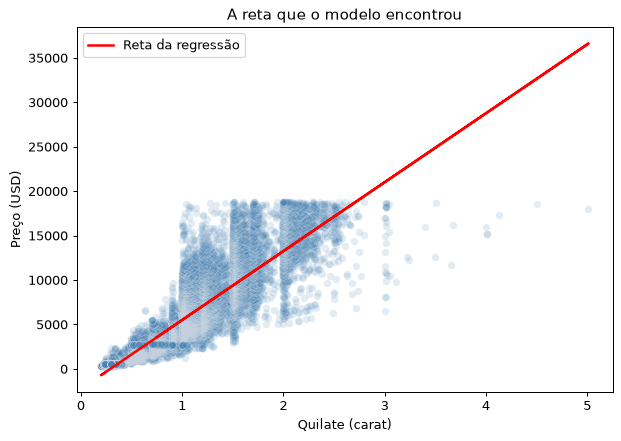

In [5]:
# A reta ajustada em cima da nuvem de pontos
plt.figure(figsize=(7, 5))
sns.scatterplot(x='carat', y='price', data=df, alpha=0.15, color='steelblue')

# Previsão do modelo para cada valor de quilate
plt.plot(df['carat'], modelo_simples.predict(X_simples),
         color='red', linewidth=2, label='Reta da regressão')

plt.title('A reta que o modelo encontrou')
plt.xlabel('Quilate (carat)')
plt.ylabel('Preço (USD)')
plt.legend()
plt.tight_layout()
plt.show()

> **Repare:** a reta não passa por cima de todos os pontos, e nem deveria. Ela representa a
> **tendência média**. A distância entre cada ponto e a reta é o **erro** daquela previsão, e é
> exatamente isso que vamos medir daqui a pouco.

## 4. Treinando o modelo (agora com todas as variáveis)

Uma variável só é didático, mas joga fora informação. Vamos usar **todas as colunas numéricas** de
uma vez. A lógica é idêntica, só que agora a "reta" existe em várias dimensões.

Antes, precisamos separar:

* **Features (X):** as colunas que usamos como entrada (as características do diamante)
* **Target (y):** a coluna que queremos prever (o preço)

In [6]:
# Separando features (X) e target (y)
features = ['carat', 'depth', 'table', 'x', 'y', 'z']

X = df[features]          # características numéricas
y = df['price']           # o que queremos prever

print(f"Formato de X: {X.shape}")   # (linhas, colunas)
print(f"Formato de y: {y.shape}")   # (linhas,)

Formato de X: (53940, 6)
Formato de y: (53940,)


In [7]:
# Criando o modelo
modelo = LinearRegression()

# Treinando: o modelo aprende a relação entre features e preço
modelo.fit(X, y)

print("Modelo treinado com sucesso! 🎉")

Modelo treinado com sucesso! 🎉


Pronto! Só isso. O scikit-learn cuida de toda a matemática por baixo do capô.

Agora vamos fazer previsões:

## 5. Fazendo Previsões

In [8]:
# Fazendo previsões
y_pred = modelo.predict(X)

# Comparando as primeiras previsões com os valores reais
comparacao = pd.DataFrame({
    'Preço Real': y.values[:10],
    'Preço Previsto': y_pred[:10].round(0)
})

print(comparacao.to_string(index=False))

 Preço Real  Preço Previsto
        326           347.0
        326           -71.0
        327           126.0
        334           194.0
        335            54.0
        336            -1.0
        336            88.0
        337           441.0
        337         -1011.0
        338            96.0


Já deu para ter uma ideia! Os valores não são idênticos (isso seria suspeito), mas estão na mesma
faixa. Vamos medir isso direito.

## 6. Avaliando o Modelo

Como saber se o modelo é bom?

Usamos métricas de erro. Vamos usar duas:

### MAE (Mean Absolute Error, ou Erro Médio Absoluto)

Em português: *"em média, o modelo erra por quantos dólares?"*

Exemplo: MAE = 800 significa que, em média, a previsão erra por ±$800.

### R² (R-quadrado)

Mede o quanto o modelo explica a variação dos preços. Vai de 0 a 1:

* 0 = o modelo não explica nada (inútil)
* 1 = o modelo é perfeito (suspeito!)
* 0.85 = o modelo explica 85% da variação nos preços (bom!)

> 💡 **Curiosidade:** no caso de uma variável só, o R² é literalmente o **quadrado da correlação**
> que vocês calcularam na Aula 3. Correlação e regressão são a mesma ideia vista de ângulos diferentes.

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y, y_pred)
r2  = r2_score(y, y_pred)

print(f"MAE (Erro Médio Absoluto): ${mae:,.0f}")
print(f"R² (quanto o modelo explica): {r2:.2%}")

MAE (Erro Médio Absoluto): $889
R² (quanto o modelo explica): 85.92%


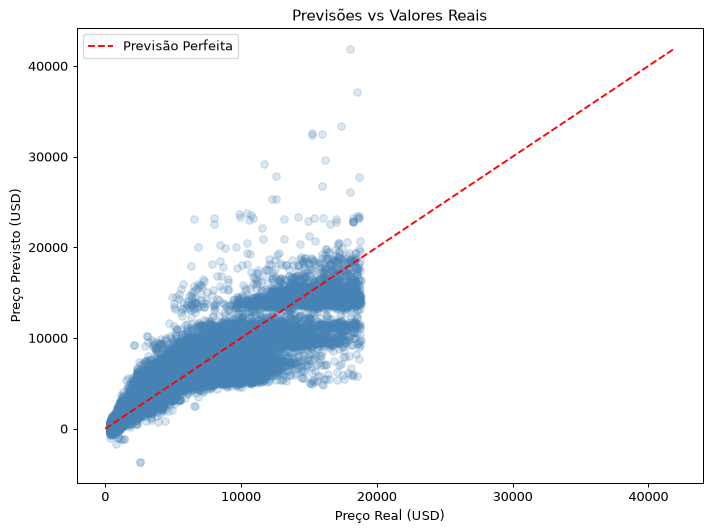

In [10]:
# Gráfico: Previsões vs Valores Reais
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.2, color='steelblue')

# Linha perfeita (onde real == previsto)
lim = max(y.max(), y_pred.max())
plt.plot([0, lim], [0, lim], color='red', linestyle='--', label='Previsão Perfeita')

plt.xlabel('Preço Real (USD)')
plt.ylabel('Preço Previsto (USD)')
plt.title('Previsões vs Valores Reais')
plt.legend()
plt.tight_layout()
plt.show()

> **O que esse gráfico mostra?** Se o modelo fosse perfeito, todos os pontos estariam em cima da
> linha vermelha. Quanto mais os pontos se dispersam, mais o modelo erra. Perceba que para diamantes
> mais caros (eixo X > 10.000), as previsões ficam mais espalhadas: a regressão linear tem limitações!

### ⚠️ Um detalhe importante (que vamos resolver na Aula 5)

Repare no que acabamos de fazer: **avaliamos o modelo nos mesmos dados em que ele treinou**.

É como corrigir a prova de um aluno usando exatamente as questões que ele estudou na véspera. A nota
sai boa, mas ela não prova que ele aprendeu de verdade.

Para o objetivo de hoje, que é entender o que é um ajuste linear, isso está de bom tamanho. Mas
guarde a inquietação: **na Aula 5 vamos aprender a avaliar um modelo de forma honesta.**

## 7. Interpretando os Coeficientes

Uma das grandes vantagens da Regressão Linear é que ela é **interpretável**: você consegue entender
o que o modelo aprendeu.

Cada coeficiente representa: *"se essa variável aumentar em 1 unidade (1 quilate, 1 mm, 1 ponto
percentual...), o preço previsto muda em X dólares"*.

In [11]:
# Extraindo os coeficientes do modelo
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(coeficientes.to_string(index=False))

Feature  Coeficiente
  carat 10686.309081
      y    66.321602
      z    41.627697
  table  -102.445652
  depth  -203.154052
      x -1315.667842


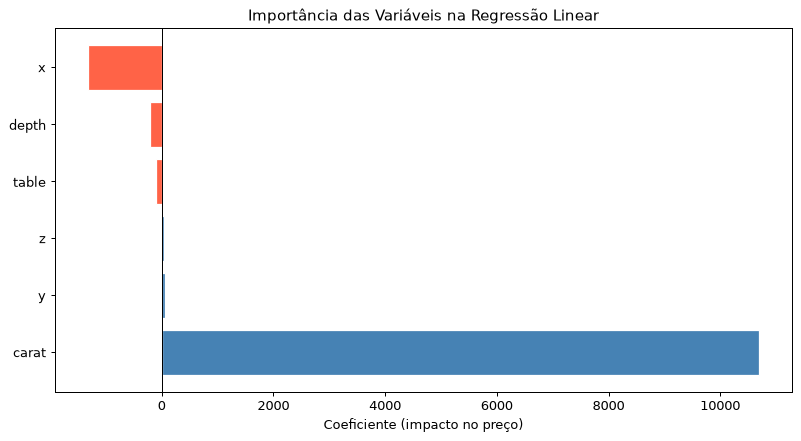

In [12]:
# Visualizando os coeficientes
cores = ['steelblue' if c > 0 else 'tomato' for c in coeficientes['Coeficiente']]

plt.figure(figsize=(9, 5))
plt.barh(coeficientes['Feature'], coeficientes['Coeficiente'], color=cores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (impacto no preço)')
plt.title('Importância das Variáveis na Regressão Linear')
plt.tight_layout()
plt.show()

### Interpretando:

* **Azul (positivo):** quando a variável aumenta, o preço tende a **subir**
* **Vermelho (negativo):** quando a variável aumenta, o preço tende a **cair**

Vamos fazer perguntas sobre o resultado:

* **`carat` tem o maior coeficiente positivo?** Faz sentido! Diamantes maiores custam mais.
* **Alguma variável tem coeficiente negativo?** Pode parecer estranho, mas lembre-se: estamos
  controlando todas as outras variáveis ao mesmo tempo. Uma variável pode ter efeito negativo quando
  combinada com as demais.
* **`x`, `y`, `z` (dimensões físicas)?** Estão correlacionadas com o quilate. Lembra do heatmap lá
  do começo da aula? O modelo pode estar tendo dificuldade de separar o efeito de cada uma.

> **Dica:** coeficientes negativos em variáveis como `depth` e `table` podem indicar que diamantes
> com proporções muito extremas (muito fundos ou muito rasos) valem menos, o que faz sentido na
> joalheria!

> ⚠️ **Cuidado ao comparar coeficientes:** cada variável está em uma unidade diferente (quilates,
> milímetros, porcentagem). Um coeficiente grande pode ser só efeito de a unidade ser pequena. Na
> **Aula 5** vamos aprender uma técnica (*scaling*) que coloca todo mundo na mesma escala justamente
> para tornar essa comparação justa.

## 🎯 Resumo da Aula

| Conceito | Em uma frase |
|---|---|
| **Regressão Linear** | Modelo que usa uma reta para prever valores numéricos |
| **Coeficiente (a)** | Quanto o alvo muda quando a variável sobe 1 unidade |
| **Intercepto (b)** | O valor base, quando todas as variáveis são zero |
| **Ajuste (`fit`)** | Encontrar a reta que minimiza os erros |
| **MAE** | Erro médio em unidade original (ex: $800 de erro médio) |
| **R²** | % da variação explicada pelo modelo |
| **Interpretabilidade** | Conseguir explicar *por que* o modelo previu aquilo |

### O gancho para a próxima aula

Hoje jogamos fora as colunas de texto (`cut`, `color`, `clarity`), usamos variáveis em escalas muito
diferentes e avaliamos o modelo nos próprios dados de treino.

Cada um desses três problemas tem uma solução. É exatamente sobre isso que é a **Aula 5**.

## 🏋️ Mão na Massa

#### Exercício 1 (fácil)

Refaça a regressão simples da seção 3, mas usando `x` (comprimento em mm) no lugar de `carat`.

* Qual é o coeficiente? Como você o traduz em português?
* O R² ficou maior ou menor que o do `carat`?

Coeficiente (a): 3,145
Intercepto  (b): -14,094
Em português: cada milímetro a mais de comprimento vale, em média, US$ 3,145 a mais.

R² usando x:     78.22%
R² usando carat: 84.93%


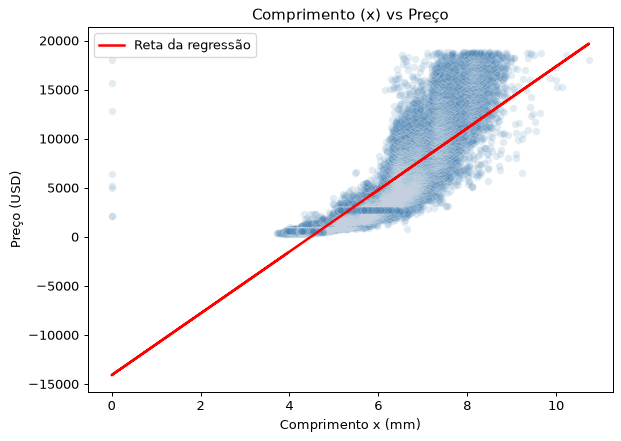

In [13]:
# Exercício 1 - regressão simples com x (comprimento) no lugar de carat
X_ex1 = df[['x']]

modelo_ex1 = LinearRegression()
modelo_ex1.fit(X_ex1, y)

a_ex1 = modelo_ex1.coef_[0]
b_ex1 = modelo_ex1.intercept_

r2_x     = r2_score(y, modelo_ex1.predict(X_ex1))
r2_carat = r2_score(y, modelo_simples.predict(X_simples))

print(f"Coeficiente (a): {a_ex1:,.0f}")
print(f"Intercepto  (b): {b_ex1:,.0f}")
print(f"Em português: cada milímetro a mais de comprimento vale, em média, US$ {a_ex1:,.0f} a mais.")
print()
print(f"R² usando x:     {r2_x:.2%}")
print(f"R² usando carat: {r2_carat:.2%}")

# A reta ajustada, para comparar visualmente com a do carat
plt.figure(figsize=(7, 5))
sns.scatterplot(x='x', y='price', data=df, alpha=0.15, color='steelblue')
plt.plot(df['x'], modelo_ex1.predict(X_ex1), color='red', linewidth=2, label='Reta da regressão')
plt.title('Comprimento (x) vs Preço')
plt.xlabel('Comprimento x (mm)')
plt.ylabel('Preço (USD)')
plt.legend()
plt.tight_layout()
plt.show()

> **✅ Resposta**
>
> **Coeficiente: 3.145.** Em português: a cada milímetro a mais de comprimento, o preço sobe em
> média US$ 3.145.
>
> **R²: 78,2%**, abaixo dos **84,9%** obtidos com `carat`. Faz sentido: `x` mede uma dimensão só,
> enquanto o quilate mede a massa, que resume as três dimensões de uma vez.
>
> Repare no intercepto: **-14.094**. Ele não tem interpretação física (um diamante de 0 mm não
> custa dinheiro negativo). Serve só para posicionar a reta na faixa de valores que existe de
> verdade na base. Esse é justamente o assunto do Exercício 3.

#### Exercício 2 (médio)

Treine o modelo usando **apenas** `carat`, `depth` e `table` (sem `x`, `y`, `z`).

* O R² caiu muito?
* O coeficiente de `carat` mudou? Por que você acha que isso aconteceu?

In [14]:
# Exercício 2 - modelo só com carat, depth e table
features_ex2 = ['carat', 'depth', 'table']

X_ex2 = df[features_ex2]
modelo_ex2 = LinearRegression()
modelo_ex2.fit(X_ex2, y)

y_pred_ex2 = modelo_ex2.predict(X_ex2)

print("Modelo completo (carat, depth, table, x, y, z):")
print(f"  R²:  {r2_score(y, y_pred):.2%}")
print(f"  MAE: ${mean_absolute_error(y, y_pred):,.0f}")
print()
print("Modelo reduzido (carat, depth, table):")
print(f"  R²:  {r2_score(y, y_pred_ex2):.2%}")
print(f"  MAE: ${mean_absolute_error(y, y_pred_ex2):,.0f}")
print()

# Como o coeficiente do carat mudou de um modelo para o outro?
coef_completo = modelo.coef_[features.index('carat')]
coef_reduzido = modelo_ex2.coef_[features_ex2.index('carat')]

print(f"Coeficiente de 'carat' no modelo completo: {coef_completo:,.0f}")
print(f"Coeficiente de 'carat' no modelo reduzido: {coef_reduzido:,.0f}")

Modelo completo (carat, depth, table, x, y, z):
  R²:  85.92%
  MAE: $889

Modelo reduzido (carat, depth, table):
  R²:  85.37%
  MAE: $994

Coeficiente de 'carat' no modelo completo: 10,686
Coeficiente de 'carat' no modelo reduzido: 7,859


> **✅ Resposta**
>
> **O R² quase não caiu:** de **85,9%** para **85,4%**. Metade de um ponto percentual foi o preço
> de jogar fora três colunas, ou seja, `x`, `y` e `z` quase não acrescentavam informação nova.
> O MAE reagiu um pouco mais, subindo de **US$ 889** para **US$ 994**.
>
> **O coeficiente de `carat` mudou bastante:** de **10.686** para **7.859**. O motivo é a alta
> correlação entre `carat` e as dimensões físicas (todas acima de 0,95 no heatmap). Com todas no
> modelo, elas dividem entre si o crédito pelo efeito do tamanho, e cada coeficiente isolado passa
> a medir uma situação que não existe no mundo real: "aumentar o quilate mantendo x, y e z
> parados". Sem as concorrentes, o `carat` volta a carregar sozinho o efeito do tamanho.
>
> Esse fenômeno tem nome: **multicolinearidade**. A lição prática é que o R² pode continuar ótimo
> enquanto os coeficientes individuais ficam instáveis e sem sentido para interpretação.

#### Exercício 3 (difícil, pensamento crítico)

Olhando o gráfico de "Previsões vs Valores Reais", o modelo erra mais nos diamantes caros. Além
disso, algumas previsões saem **negativas**, e preço negativo não existe!

* Encontre quantas previsões ficaram abaixo de zero.
* Por que uma reta pode prever valores negativos?
* O que isso diz sobre os limites de usar uma reta para descrever esse fenômeno?

Previsões abaixo de zero: 506 de 53940 (0.94%)
Previsão mais negativa:   $-3,676

Perfil dos diamantes com previsão negativa (vs. base inteira):
       previsão negativa  base inteira
carat               0.27          0.80
x                   4.11          5.73
price             575.80       3932.80


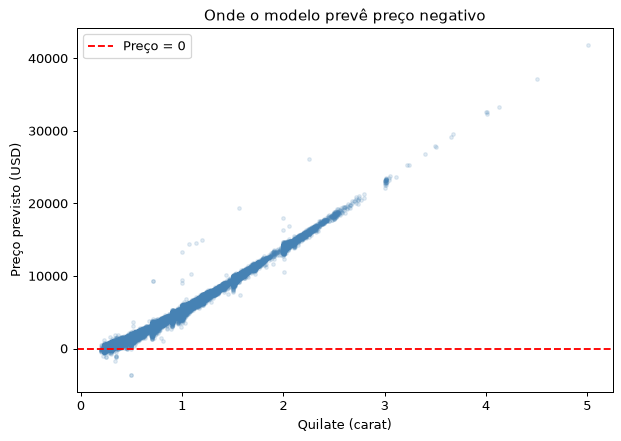

In [15]:
# Exercício 3 - previsões negativas
negativas = y_pred < 0

print(f"Previsões abaixo de zero: {negativas.sum()} de {len(y_pred)} ({negativas.mean():.2%})")
print(f"Previsão mais negativa:   ${y_pred.min():,.0f}")
print()

# Como são os diamantes que receberam previsão negativa?
print("Perfil dos diamantes com previsão negativa (vs. base inteira):")
comparacao_neg = pd.DataFrame({
    'previsão negativa': df.loc[negativas, ['carat', 'x', 'price']].mean(),
    'base inteira':      df[['carat', 'x', 'price']].mean(),
}).round(2)
print(comparacao_neg.to_string())

plt.figure(figsize=(7, 5))
plt.scatter(df['carat'], y_pred, alpha=0.15, color='steelblue', s=8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Preço = 0')
plt.title('Onde o modelo prevê preço negativo')
plt.xlabel('Quilate (carat)')
plt.ylabel('Preço previsto (USD)')
plt.legend()
plt.tight_layout()
plt.show()

> **✅ Resposta**
>
> **Quantas:** **506 previsões** ficam abaixo de zero (0,94% da base), e a pior chega a
> **-US$ 3.676**. São diamantes pequenos: 0,27 quilate em média, contra 0,80 da base inteira, e
> preço real médio de US$ 576.
>
> **Por que uma reta faz isso:** a reta é infinita nas duas direções e nada no modelo diz que preço
> não pode ser negativo. Como ela precisa acompanhar a subida forte dos diamantes grandes, a
> inclinação fica alta e o intercepto vai lá para baixo, arrastando a ponta esquerda da reta para
> o campo negativo.
>
> **O que isso revela:** a relação entre tamanho e preço não é reta, é curva (o preço acelera nos
> diamantes grandes). A reta é uma boa aproximação no meio da distribuição e ruim nas pontas.
>
> Três saídas usadas na prática:
> 1. modelar `log(price)` em vez de `price`, o que impede previsão negativa e lineariza a curva;
> 2. usar um modelo não linear, como árvores;
> 3. no mínimo, truncar as previsões em zero antes de entregar o resultado para alguém.